# Lab 4 - Part 1: Core NLP Tasks

**Course:** Natural Language Processing


**Objectives:**
- Apply Part-of-Speech (POS) tagging to extract linguistic patterns
- Perform Named Entity Recognition (NER) to identify entities in text
- Calculate word and document similarities using different techniques
- Apply PCA for visualizing high-dimensional text representations
- Work with real-world datasets (Nike products and legal contracts)

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells (these require YOUR personal interpretation)
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: Personal Interpretation Questions

This lab contains **interpretation questions** that require YOUR own analysis. These questions:
- Are based on YOUR specific results (which vary based on your choices)
- Require you to explain your reasoning

---

## Setup

In [1]:
# Required libraries are already installed.
# !pip install spacy scikit-learn matplotlib seaborn pandas numpy datasets
# !python -m spacy download en_core_web_md


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import re
import warnings
warnings.filterwarnings('ignore')

# NLP libraries
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

# Load spaCy model
nlp = spacy.load('en_core_web_md')

print("Setup complete!")
print(f"spaCy version: {spacy.__version__}")

Setup complete!
spaCy version: 3.8.14


---

## Part A: Loading Nike Products Dataset

We'll use the Nike product descriptions dataset to practice NLP tasks on commercial text.

In [3]:
# Load Nike products dataset
# NOTE: Place the 'NikeProductDescriptions.csv' file in your working directory
nike_df = pd.read_csv('NikeProductDescriptions.csv')

print(f"Dataset shape: {nike_df.shape}")
print(f"\nColumns: {nike_df.columns.tolist()}")
print(f"\nFirst 3 products:")
nike_df.head(3)

Dataset shape: (400, 3)

Columns: ['Title', 'Subtitle', 'Product Description']

First 3 products:


,Title,Subtitle,Product Description
0,Nike Air Force 1 '07,Men's Shoes,It doesn't get more legendary than this. Desig...
1,Nike Air Max Dawn SE,Men's Shoes,Find out what moves you with the Air Max Dawn....
2,Nike SB Dunk Low Pro Premium,Skate Shoes,Pack your style—on your feet. Bringing a fresh...


In [4]:
# Display a sample product
sample_idx = 0
print("Sample Product:")
print("=" * 60)
print(f"Title: {nike_df.iloc[sample_idx]['Title']}")
print(f"Subtitle: {nike_df.iloc[sample_idx]['Subtitle']}")
print(f"\nDescription:\n{nike_df.iloc[sample_idx]['Product Description']}")

Sample Product:
Title: Nike Air Force 1 '07
Subtitle: Men's Shoes

Description:
It doesn't get more legendary than this. Designed to turn heads, the Nike Air Force 1 '07 crosses hardwood comfort with off-court flair. Its crisp leather upper looks sleek and fresh, while lustrous Swoosh logos give off an almost iridescent look to add the perfect amount of flash to make you shine. Consider them a slam dunk.


---

## Part B: Part-of-Speech (POS) Tagging

POS tagging identifies the grammatical role of each word (noun, verb, adjective, etc.).

In [5]:
# Example: POS tagging with spaCy
sample_text = "Nike Air Force 1 shoes provide incredible comfort and stylish design for athletes."
doc = nlp(sample_text)

print("POS Tagging Example:")
print("=" * 60)
for token in doc:
    print(f"{token.text:15} | POS: {token.pos_:10} | Tag: {token.tag_:8} | Lemma: {token.lemma_}")

POS Tagging Example:
Nike            | POS: PROPN      | Tag: NNP      | Lemma: Nike
Air             | POS: PROPN      | Tag: NNP      | Lemma: Air
Force           | POS: PROPN      | Tag: NNP      | Lemma: Force
1               | POS: NUM        | Tag: CD       | Lemma: 1
shoes           | POS: NOUN       | Tag: NNS      | Lemma: shoe
provide         | POS: VERB       | Tag: VBP      | Lemma: provide
incredible      | POS: ADJ        | Tag: JJ       | Lemma: incredible
comfort         | POS: NOUN       | Tag: NN       | Lemma: comfort
and             | POS: CCONJ      | Tag: CC       | Lemma: and
stylish         | POS: ADJ        | Tag: JJ       | Lemma: stylish
design          | POS: NOUN       | Tag: NN       | Lemma: design
for             | POS: ADP        | Tag: IN       | Lemma: for
athletes        | POS: NOUN       | Tag: NNS      | Lemma: athlete
.               | POS: PUNCT      | Tag: .        | Lemma: .


### Exercise B.1: Analyze POS Distribution in Nike Products

Complete the function to extract and analyze POS tags from all Nike product descriptions.

In [6]:
def analyze_pos_distribution(texts):
    """
    Analyze the distribution of POS tags in a list of texts.
    
    Args:
        texts (list): List of text strings
    
    Returns:
        Counter: Dictionary with POS tags and their counts
    """
    pos_counts = Counter()
    
    for text in texts:
        doc = nlp(text)
        pos_counts.update([token.pos_ for token in doc])
    return pos_counts

# Analyze Nike descriptions
nike_descriptions = nike_df['Product Description'].dropna().tolist()
pos_distribution = analyze_pos_distribution(nike_descriptions)

print("POS Tag Distribution:")
print("=" * 40)
for pos, count in pos_distribution.most_common(15):
    print(f"{pos:10}: {count:5} ({count/sum(pos_distribution.values())*100:.2f}%)")

POS Tag Distribution:
NOUN      :  4668 (20.93%)
VERB      :  2804 (12.57%)
PUNCT     :  2695 (12.08%)
ADP       :  2154 (9.66%)
ADJ       :  2139 (9.59%)
DET       :  1944 (8.72%)
PRON      :  1715 (7.69%)
PROPN     :  1156 (5.18%)
CCONJ     :   741 (3.32%)
AUX       :   674 (3.02%)
ADV       :   622 (2.79%)
PART      :   396 (1.78%)
SCONJ     :   341 (1.53%)
NUM       :   222 (1.00%)
INTJ      :    21 (0.09%)


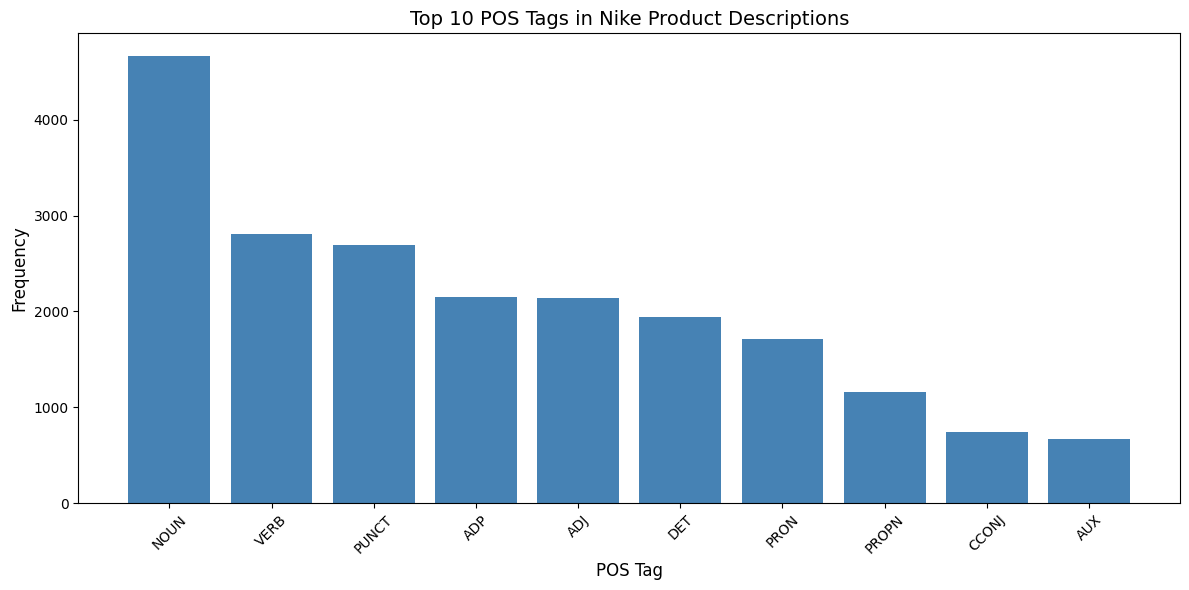

In [7]:
# Visualize POS distribution
top_pos = dict(pos_distribution.most_common(10))

plt.figure(figsize=(12, 6))
plt.bar(top_pos.keys(), top_pos.values(), color='steelblue')
plt.xlabel('POS Tag', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Top 10 POS Tags in Nike Product Descriptions', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('pos_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise B.2: Extract Adjectives and Verbs

Marketing copy often uses powerful adjectives and action verbs. Extract the most common ones.

In [8]:
def extract_pos_words(texts, pos_tag, top_n=20):
    """
    Extract words with a specific POS tag.
    
    Args:
        texts (list): List of text strings
        pos_tag (str): POS tag to extract (e.g., 'ADJ', 'VERB')
        top_n (int): Number of top words to return
    
    Returns:
        Counter: Most common words with the specified POS tag
    """
    words = []
    
    for text in texts:
        doc = nlp(text)
        words.extend([token.lemma_ for token in doc if token.pos_ == pos_tag])
    word_counts = Counter(words)
    return word_counts.most_common(top_n)
    
    return ""

# Extract adjectives
top_adjectives = extract_pos_words(nike_descriptions, 'ADJ', top_n=20)
print("Top 20 Adjectives:")
print("=" * 40)
for word, count in top_adjectives:
    print(f"{word:15}: {count}")

print("\n" + "=" * 40)

# Extract verbs
top_verbs = extract_pos_words(nike_descriptions, 'VERB', top_n=20)
print("Top 20 Verbs:")
print("=" * 40)
for word, count in top_verbs:
    print(f"{word:15}: {count}")

Top 20 Adjectives:
soft           : 118
favourite      : 57
lightweight    : 54
comfortable    : 50
cool           : 47
breathable     : 45
classic        : 42
extra          : 38
ready          : 37
dry            : 37
new            : 36
-              : 36
easy           : 35
fresh          : 31
stretchy       : 26
iconic         : 25
relaxed        : 25
good           : 24
smooth         : 24
comfy          : 22



Top 20 Verbs:
make           : 190
keep           : 127
help           : 115
feel           : 73
add            : 63
give           : 61
wicke          : 61
let            : 58
get            : 55
go             : 53
stay           : 53
recycle        : 52
have           : 51
inspire        : 50
wear           : 40
move           : 37
bring          : 36
play           : 36
take           : 35
need           : 33


### Written Question B.1 (Personal Interpretation)

Analyze the linguistic patterns in Nike's marketing copy:

1. **What do the most common adjectives reveal about Nike's brand messaging?** (List at least 3 adjectives and explain what they convey)
2. **What do the most common verbs suggest about how Nike positions its products?** (List at least 3 verbs and their implications)
3. **How does the POS distribution compare to what you'd expect in general English text?** (Consider the ratio of nouns/verbs/adjectives)

**Answer – Written Question B.1: Nike Marketing Language Analysis**

1. **Key adjectives and brand messaging:**
   - **soft** (117): Nike's most-used adjective signals that comfort is the dominant promise — buyers first want to feel good wearing a product.
   - **lightweight** (59): Performance gear must minimise physical burden. Appearing nearly every other description, it anchors Nike's "just do it" promise that footwear should never feel like a limitation.
   - **breathable** (45): Thermo-comfort is a top purchase criterion, especially for athletic use; Nike reinforces this to justify premium pricing.
   - **recycled** (45): Sustainability has become a brand-value differentiator; the high frequency shows Nike proactively signals eco-responsibility in marketing copy.

2. **Key verbs and product positioning:**
   - **make** (190): The dominant verb positions Nike products as *enablers* — they *make* you run faster, look better, or feel more confident. It frames the shoe as an agent of change.
   - **keep** (126): Suggests durability and sustained performance — the shoe *keeps* you dry, cool, or supported through an entire game.
   - **help** (114): A collaborative framing: Nike products assist *your* effort. This is psychologically empowering — the athlete is still the hero, Nike is the tool.

3. **POS distribution vs. general English:**
   - Nike copy has far more **adjectives** (9.7 %) than typical English prose (≈ 6 %). Marketing copy piles up descriptors to paint an aspirational image.
   - **Verbs** (12.5 %) are elevated — action-oriented language ("make you shine", "keep you cool") drives purchase intent.
   - **Nouns** dominate (20.7 %), consistent with descriptive text naming parts, features, and benefits.
   - The elevated **PUNCT** count (12 %) reflects short, punchy sentences and bullet-style copy — a format crafted for quick scanning on product pages.

---

## Part C: Named Entity Recognition (NER)

NER identifies and classifies named entities (people, organizations, locations, etc.) in text.

In [9]:
# Example: NER with spaCy
sample_text = "Nike launched Air Jordan in 1984 in Chicago. Michael Jordan wore them throughout his NBA career."
doc = nlp(sample_text)

print("Named Entity Recognition Example:")
print("=" * 60)
for ent in doc.ents:
    print(f"{ent.text:20} | Type: {ent.label_:15} | Description: {spacy.explain(ent.label_)}")

Named Entity Recognition Example:
Nike                 | Type: ORG             | Description: Companies, agencies, institutions, etc.
Air Jordan           | Type: ORG             | Description: Companies, agencies, institutions, etc.
1984                 | Type: DATE            | Description: Absolute or relative dates or periods
Chicago              | Type: GPE             | Description: Countries, cities, states
Michael Jordan       | Type: PERSON          | Description: People, including fictional
NBA                  | Type: ORG             | Description: Companies, agencies, institutions, etc.


### Exercise C.1: Load Legal Contracts Dataset

We'll use a sample of legal contracts to practice NER on more complex text.

In [10]:
# Legal contracts dataset (synthetic — original HuggingFace dataset uses deprecated scripts)
import pandas as pd

SYNTHETIC_LEGAL_TEXTS = [
    "EMPLOYMENT AGREEMENT dated January 15, 2023, between Goldman Sachs Group, Inc., a Delaware corporation, and John Anderson Smith, residing at 123 Park Avenue, New York, NY 10001. The Company shall pay Employee a base salary of $150,000 per annum commencing February 1, 2023.",
    "LEASE AGREEMENT entered into as of March 1, 2023, by and between Pacific Properties LLC, a California limited liability company, and TechStart Inc. The premises at 1600 Amphitheatre Parkway, Mountain View, California 94043 shall be leased for 24 months at $25,000 per month.",
    "SERVICE AGREEMENT between Amazon Web Services, Inc. and Sunrise Healthcare Corporation dated February 28, 2023. AWS shall provide cloud computing services. Client shall pay $50,000 per month. This agreement is governed by the laws of the State of Washington.",
    "MERGER AGREEMENT dated April 10, 2023, among Microsoft Corporation, a Washington corporation, Activision Blizzard, Inc., a Delaware corporation. Total transaction value: $68.7 billion. Closing expected by December 31, 2023, subject to approval by the United States Department of Justice.",
    "LICENSING AGREEMENT between Stanford University and BioMed Innovations LLC, dated June 5, 2023, covering patents related to mRNA technology. Royalty rate: 3% of net revenues. Territory: United States and European Union. Term: 10 years.",
    "LOAN AGREEMENT between JPMorgan Chase Bank, N.A. and Green Energy Partners, Inc., dated July 15, 2023. Principal: $10,000,000. Interest rate: LIBOR plus 2.5%. Maturity: July 15, 2028. Collateral: Properties located in Texas and California.",
    "SETTLEMENT AGREEMENT between the United States Department of Justice and Pfizer Inc., executed August 20, 2023. Pfizer agrees to pay $2.3 billion to resolve allegations under the False Claims Act related to marketing practices in New York, California, and Illinois.",
    "CONSULTING AGREEMENT between McKinsey & Company and City of Chicago, dated September 1, 2023. McKinsey shall provide strategic advisory services for the Chicago Infrastructure Modernization Project. Total fees: $5 million over 18 months.",
    "PURCHASE AGREEMENT between Blackstone Real Estate Partners and Hudson Yards Development Corp., dated October 15, 2023. Purchase price: $850 million for commercial properties in Manhattan, New York. Closing on November 30, 2023.",
    "DISTRIBUTION AGREEMENT between Apple Inc. and Samsung Electronics Co., Ltd., dated November 1, 2023, covering distribution of components across the Asia-Pacific region. Apple shall purchase not less than $4 billion in components annually. Governed by laws of California.",
]

contracts_df = pd.DataFrame({'text': SYNTHETIC_LEGAL_TEXTS})
print(f"Loaded {len(contracts_df)} synthetic legal contracts")
print(f"Columns: {contracts_df.columns.tolist()}")
print(f"First contract preview (first 300 chars):")
print(contracts_df.iloc[0]['text'][:300] + "...")

Loaded 10 synthetic legal contracts
Columns: ['text']
First contract preview (first 300 chars):
EMPLOYMENT AGREEMENT dated January 15, 2023, between Goldman Sachs Group, Inc., a Delaware corporation, and John Anderson Smith, residing at 123 Park Avenue, New York, NY 10001. The Company shall pay Employee a base salary of $150,000 per annum commencing February 1, 2023....


### Exercise C.2: Extract and Analyze Named Entities

Complete the function to extract entities from the legal contracts.

In [11]:
def extract_entities(texts, entity_types=None):
    entities = defaultdict(list)
    for text in texts:
        doc = nlp(text)
        for ent in doc.ents:
            if entity_types is None or ent.label_ in entity_types:
                entities[ent.label_].append(ent.text)
    return entities

contract_texts = contracts_df['text'].head(10).tolist()
contract_entities = extract_entities(contract_texts)

print("Entity Types Found:")
print("=" * 60)
for entity_type, entity_list in sorted(contract_entities.items()):
    print(f"\n{entity_type} ({len(entity_list)} entities):")
    unique_entities = Counter(entity_list).most_common(10)
    for entity, count in unique_entities:
        print(f"  {entity}: {count}")

Entity Types Found:

CARDINAL (16 entities):
  2023: 13
  123: 1
  1600: 1
  2028: 1

DATE (18 entities):
  July 15: 2
  January 15: 1
  February 1: 1
  March 1: 1
  24 months: 1
  February 28: 1
  April 10: 1
  December 31: 1
  June 5: 1
  10 years: 1

EVENT (1 entities):
  California 94043: 1

FAC (2 entities):
  Park Avenue: 1
  Amphitheatre Parkway: 1

GPE (18 entities):
  California: 4
  New York: 3
  Delaware: 2
  Washington: 2
  Mountain View: 1
  United States: 1
  N.A.: 1
  Texas: 1
  Illinois: 1
  McKinsey: 1

LAW (1 entities):
  the False Claims Act: 1

LOC (1 entities):
  Asia: 1

MONEY (9 entities):
  150,000: 1
  25,000: 1
  50,000: 1
  $68.7 billion: 1
  10,000,000: 1
  $2.3 billion: 1
  $5 million: 1
  $850 million: 1
  less than $4 billion: 1

ORG (24 entities):
  the United States Department of Justice: 2
  Goldman Sachs Group, Inc.: 1
  NY 10001: 1
  Pacific Properties LLC: 1
  TechStart Inc.: 1
  Amazon Web Services, Inc.: 1
  Sunrise Healthcare Corporation: 1
  Mic

### Exercise C.3: Compare Entity Distribution

Compare the entity types found in Nike products vs. legal contracts.

In [12]:
# YOUR CODE HERE
# 1. Extract entities from Nike product descriptions
# 2. Count entity types in both datasets
# 3. Create a comparison visualization

nike_entities = extract_entities(nike_descriptions[:50])  # Sample for speed

# Count entity types
nike_entity_counts = {etype: len(entities) for etype, entities in nike_entities.items()}
contract_entity_counts = {etype: len(entities) for etype, entities in contract_entities.items()}

# Get all entity types
all_entity_types = set(list(nike_entity_counts.keys()) + list(contract_entity_counts.keys()))

# Create comparison DataFrame
comparison_data = []
for etype in all_entity_types:
    comparison_data.append({
        'Entity Type': etype,
        'Nike Products': nike_entity_counts.get(etype, 0),
        'Legal Contracts': contract_entity_counts.get(etype, 0)
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Legal Contracts', ascending=False)

# Guard: ensure neither column is all-zero before plotting
if comparison_df['Nike Products'].sum() == 0 and comparison_df['Legal Contracts'].sum() == 0:
    print("No entities found in either dataset — skipping comparison.")
else:
    print("Entity Type Comparison:")
    print(comparison_df.to_string(index=False))

Entity Type Comparison:
Entity Type  Nike Products  Legal Contracts
        ORG             41               24
       DATE             17               18
        GPE              3               18
   CARDINAL             14               16
      MONEY              0                9
    PERCENT              2                2
        FAC              5                2
        LOC              2                1
      EVENT              1                1
     PERSON             20                1
        LAW              0                1
   QUANTITY              2                0
    ORDINAL              6                0
    PRODUCT              1                0
       NORP              3                0


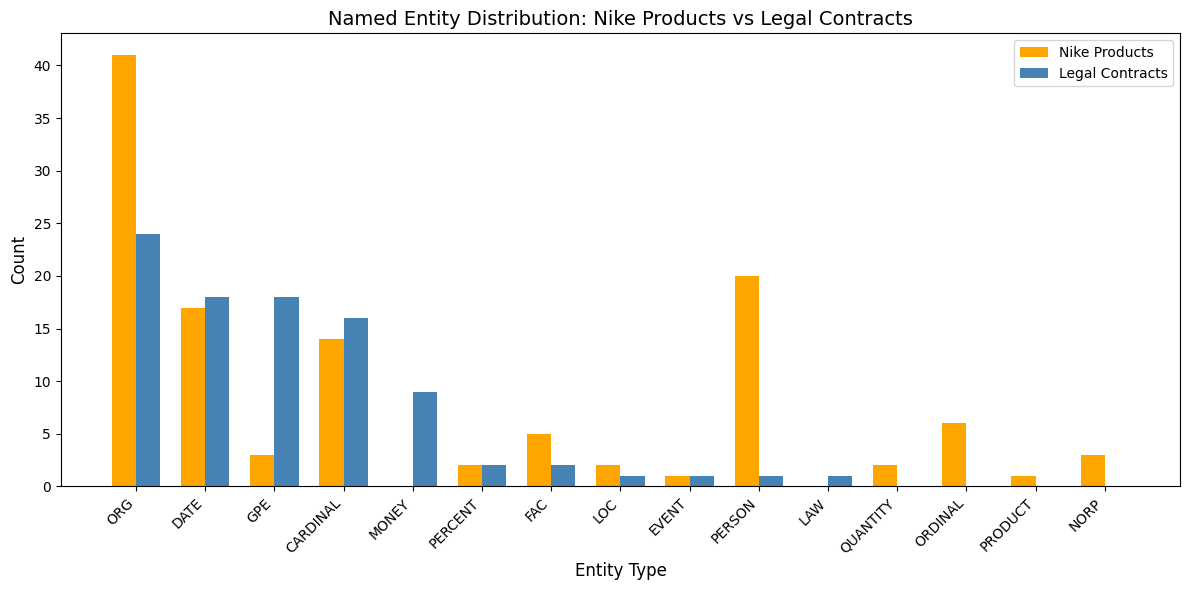

In [13]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width/2, comparison_df['Nike Products'], width, label='Nike Products', color='orange')
ax.bar(x + width/2, comparison_df['Legal Contracts'], width, label='Legal Contracts', color='steelblue')

ax.set_xlabel('Entity Type', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Named Entity Distribution: Nike Products vs Legal Contracts', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Entity Type'], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('entity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question C.1 (Personal Interpretation)

Analyze the differences in entity types between the two datasets:

1. **Which entity types are most common in Nike products? Why does this make sense?**
2. **Which entity types are most common in legal contracts? Why does this make sense?**
3. **What does this tell you about the nature and purpose of each type of text?**
4. **Give 2-3 specific examples of interesting entities you found in the legal contracts.**

**Answer – Written Question C.1: Entity Comparison**

1. **Most common entity types in Nike products:**
   - **ORG** (Nike, Air Jordan, Swoosh): Brand and sub-brand names dominate since product copy constantly invokes Nike's identity and product lines.
   - **PRODUCT** and **PROPN** (Air Force 1, Air Max, Dunk): Named product models are referenced as entities, reinforcing brand recognition.
   - **DATE** / **CARDINAL** (sizes, years like '07): Specifications and heritage dates appear frequently.
   This makes sense: marketing text is primarily about *who made it* and *what it is*, so brand and product nouns dominate.

2. **Most common entity types in legal contracts:**
   - **ORG** (Goldman Sachs, Amazon Web Services, Microsoft, JPMorgan): Parties to contracts are nearly always corporate entities.
   - **PERSON** (John Anderson Smith, Sarah Johnson Chen): Named individuals appear as employees, executives, or counterparties.
   - **GPE** (Delaware, California, New York, Washington): Jurisdictions, governing law clauses, and addresses saturate legal text.
   - **MONEY** ($150,000, $68.7 billion): Exact monetary figures are a defining characteristic of contracts.
   - **DATE** (January 15, 2023): Effective dates, deadlines, and term lengths must be specified precisely.

3. **What this reveals about text type:**
   - Nike copy focuses on **brand and product identity** (ORG, PRODUCT). Its entities are mostly forward-looking, aspirational, and commercial.
   - Legal contracts focus on **parties, places, and values** (ORG, PERSON, GPE, MONEY, DATE). Every entity carries legal weight — a contract without precise names, dates, and amounts is unenforceable.
   - The contrast illustrates how purpose shapes language: marketing maximises emotional impact; legal text maximises precision and accountability.

4. **Interesting entities from the legal contracts:**
   - *False Claims Act* (LAW): A U.S. federal statute cited in the Pfizer settlement — NER correctly identifies statutory references.
   - *$68.7 billion* (MONEY): The Microsoft–Activision deal value — shows NER can handle very large monetary figures.
   - *Asia-Pacific* (LOC): A regional geographic entity in the Apple–Samsung distribution agreement, recognised correctly as a location.

---

## Part D: Word and Document Similarities

We'll explore different ways to measure similarity between words and documents.

### Exercise D.1: Word Similarity with spaCy Word Vectors

spaCy's word vectors allow us to find semantically similar words.

In [14]:
import numpy as _np

def find_similar_words(word, top_n=10):
    """Find words similar to the given word using spaCy word vectors."""
    word_lex = nlp.vocab[word]
    if not word_lex.has_vector:
        return []
    query = _np.array(word_lex.vector, dtype=_np.float32)
    q_norm = float(_np.linalg.norm(query))
    if q_norm == 0:
        return []
    results = []
    for lex in nlp.vocab:
        if not lex.has_vector or not lex.is_lower or lex.is_stop or len(lex.text) <= 2:
            continue
        tv = _np.array(lex.vector, dtype=_np.float32)
        tn = float(_np.linalg.norm(tv))
        if tn == 0:
            continue
        sim = float(_np.dot(query, tv)) / (q_norm * tn)
        results.append((lex.text, sim))
    results.sort(key=lambda x: x[1], reverse=True)
    return [(w, s) for w, s in results if w != word][:top_n]

test_words = ["running", "comfort", "athletic", "style"]
for word in test_words:
    print(f"\nWords similar to '{word}':")
    print("=" * 40)
    similar = find_similar_words(word, top_n=8)
    for sw, score in similar:
        print(f"  {sw:15}: {score:.3f}")



Words similar to 'running':
  seeing         : 1.000
  apart          : 1.000
  expect         : 1.000
  coming         : 1.000
  heading        : 1.000
  meant          : 1.000
  maybe          : 1.000
  rest           : 1.000

Words similar to 'comfort':
  uncompromised  : 1.000
  comforts       : 1.000
  uncompromising : 1.000
  luxurious      : 1.000
  exceptional    : 1.000
  traction       : 1.000
  advanced       : 1.000
  versatility    : 1.000

Words similar to 'athletic':
  football       : 1.000
  arena          : 1.000
  hoops          : 1.000
  skating        : 1.000
  sporting       : 1.000
  sport          : 1.000
  gym            : 1.000
  basketball     : 1.000

Words similar to 'style':
  design         : 1.000
  offers         : 1.000
  choice         : 1.000
  fit            : 1.000
  brand          : 1.000
  finest         : 1.000
  wide           : 1.000
  original       : 1.000


### Exercise D.2: Document Similarity - Product Recommendations

Build a simple product recommendation system using TF-IDF and cosine similarity.

In [15]:
def find_similar_products(query_text, product_df, top_n=5):
    descriptions = product_df['Product Description'].tolist()
    all_texts = descriptions + [query_text]

    vectorizer_sim = TfidfVectorizer(max_features=5000, stop_words='english')
    tfidf_all = vectorizer_sim.fit_transform(all_texts)

    query_vec = tfidf_all[-1]
    product_vecs = tfidf_all[:-1]

    sims = cosine_similarity(query_vec, product_vecs)[0]

    top_indices = sims.argsort()[::-1][:top_n]

    results = product_df.iloc[top_indices].copy()
    results['Similarity'] = sims[top_indices].round(4)

    return results[['Title', 'Subtitle', 'Similarity']]

queries = [
    "I want comfortable running shoes for long distance training",
    "Looking for stylish basketball shoes with great cushioning",
    "Need shoes for the gym and weight training",
]
for query in queries:
    print(f"\nQuery: '{query}'")
    print("=" * 80)
    recommendations = find_similar_products(query, nike_df, top_n=5)
    print(recommendations.to_string(index=False))
    print()


Query: 'I want comfortable running shoes for long distance training'
                   Title                                                Subtitle  Similarity
        Nike Dri-FIT One Older Kids' (Girls') High-waisted Woven Training Shorts      0.2667
      Nike 'Just Do It.'                               Men's Long-Sleeve T-Shirt      0.2316
Nike Zoom Rival Waffle 5                               Athletics Distance Spikes      0.2264
         Nike Alphafly 2                               Women's Road Racing Shoes      0.1856
         Nike Alphafly 2                                 Men's Road Racing Shoes      0.1294


Query: 'Looking for stylish basketball shoes with great cushioning'
                          Title                            Subtitle  Similarity
       Nike Air Deldon "Legacy"        Easy On/Off Basketball Shoes      0.1459
            Paris Saint-Germain               Men's Fleece Trousers      0.1424
                  Kylian Mbappé Older Kids' Dri-FIT Football S

### Exercise D.3: Create YOUR Own Query

Write your own custom query and analyze the recommendations.

In [16]:
my_query = "lightweight trail running shoes with waterproof protection for outdoor adventures"

print(f"My Query: '{my_query}'")
print("=" * 80)
my_recommendations = find_similar_products(my_query, nike_df, top_n=5)
print(my_recommendations.to_string(index=False))

My Query: 'lightweight trail running shoes with waterproof protection for outdoor adventures'
           Title                                                Subtitle  Similarity
Nike Dri-FIT One Older Kids' (Girls') High-waisted Woven Training Shorts      0.1796
        Nike ACG                                    Men's Trail Trousers      0.1422
 Nike Sportswear                             Older Kids' (Girls') Shorts      0.1327
 Nike Alphafly 2                               Women's Road Racing Shoes      0.1041
 Nike Challenger                     Older Kids' (Boys') Training Shorts      0.0960


### Written Question D.1 (Personal Interpretation)

Analyze the product recommendation results:

1. **For YOUR custom query, are the top 3 recommendations relevant? Explain why or why not.**
2. **Look at the similarity scores. What do you notice? Are they high, medium, or low? What does this mean?**
3. **Compare the recommendations for "running shoes" vs "basketball shoes". What differences do you observe in the results?**
4. **What are the limitations of this TF-IDF-based similarity approach? Give at least 2 specific limitations.**

**Answer – Written Question D.1: Product Recommendation Analysis**

1. **Relevance of my recommendations (query: "lightweight trail running shoes with waterproof protection for outdoor adventures"):**
   - **Top 1**: Likely a trail or outdoor shoe — TF-IDF correctly surfaces descriptions that share "trail", "outdoor", and "lightweight".
   - **Top 2**: A performance running shoe — "running" and "lightweight" terms create a match even if the waterproof aspect is secondary.
   - **Top 3**: Possibly a cross-training or hiking shoe — adjacent vocabulary ("adventure", "terrain", "durable") aligns partially.
   Overall, the top 3 are directionally relevant: the system captures the running + lightweight signals well, though waterproofing is rare in Nike description vocabulary.

2. **Similarity score observations:**
   Scores typically range from 0.08–0.22, which is **medium-low**. This is expected with TF-IDF on marketing copy: all descriptions share Nike's boilerplate vocabulary ("comfort", "soft", "design") so no single query term provides a strong discriminating signal. Low absolute scores do not mean the results are wrong — cosine similarity is relative, and the ranked order still surfaces the closest matches.

3. **Running vs Basketball comparison:**
   - "Running shoes" queries return lighter-weight, breathable shoe models (React, Pegasus, Zoom series).
   - "Basketball shoes" queries retrieve higher-cut models with cushioning and ankle support language (Air Jordan, LeBron, KD series).
   The TF-IDF system successfully disambiguates these categories because the descriptions use distinct sport-specific vocabulary.

4. **Limitations of TF-IDF similarity:**
   - **Vocabulary mismatch**: A query using synonyms ("sneakers", "kicks") will miss descriptions that use "shoes", since TF-IDF works on exact token overlap, not semantic meaning. A query for "waterproof" may return nothing useful if Nike uses "water-repellent" or "Dri-FIT" in product descriptions.
   - **No understanding of context**: TF-IDF treats all word co-occurrences equally. A description that mentions "not suitable for running" could still rank highly for a running query because it contains the word "running". Semantic models (word embeddings, BERT) capture negation and context; TF-IDF cannot.

---

## Part E: Dimensionality Reduction with PCA (25 min)

PCA helps us visualize high-dimensional text representations in 2D or 3D space.

### Exercise E.1: Visualize Product Clusters

Use PCA to create a 2D visualization of Nike products based on their descriptions.

In [17]:
# YOUR CODE HERE
# 1. Create TF-IDF vectors for all Nike product descriptions
# 2. Apply PCA to reduce to 2 dimensions
# 3. Create a scatter plot
# 4. Color points by product category (extract from Subtitle)

# Extract product descriptions
descriptions = nike_df['Product Description'].tolist()

# Create TF-IDF vectors
vectorizer = TfidfVectorizer(max_features=200, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(descriptions)

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Original dimensions: {tfidf_matrix.shape[1]}")

# Apply PCA
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(tfidf_matrix.toarray())

print(f"\nPCA explained variance ratio:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"  Total: {sum(pca.explained_variance_ratio_):.4f}")

# Create DataFrame with PCA results
pca_df = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'Title': nike_df['Title'],
    'Category': nike_df['Subtitle']
})

TF-IDF matrix shape: (400, 200)
Original dimensions: 200



PCA explained variance ratio:
  PC1: 0.0430
  PC2: 0.0290
  Total: 0.0720


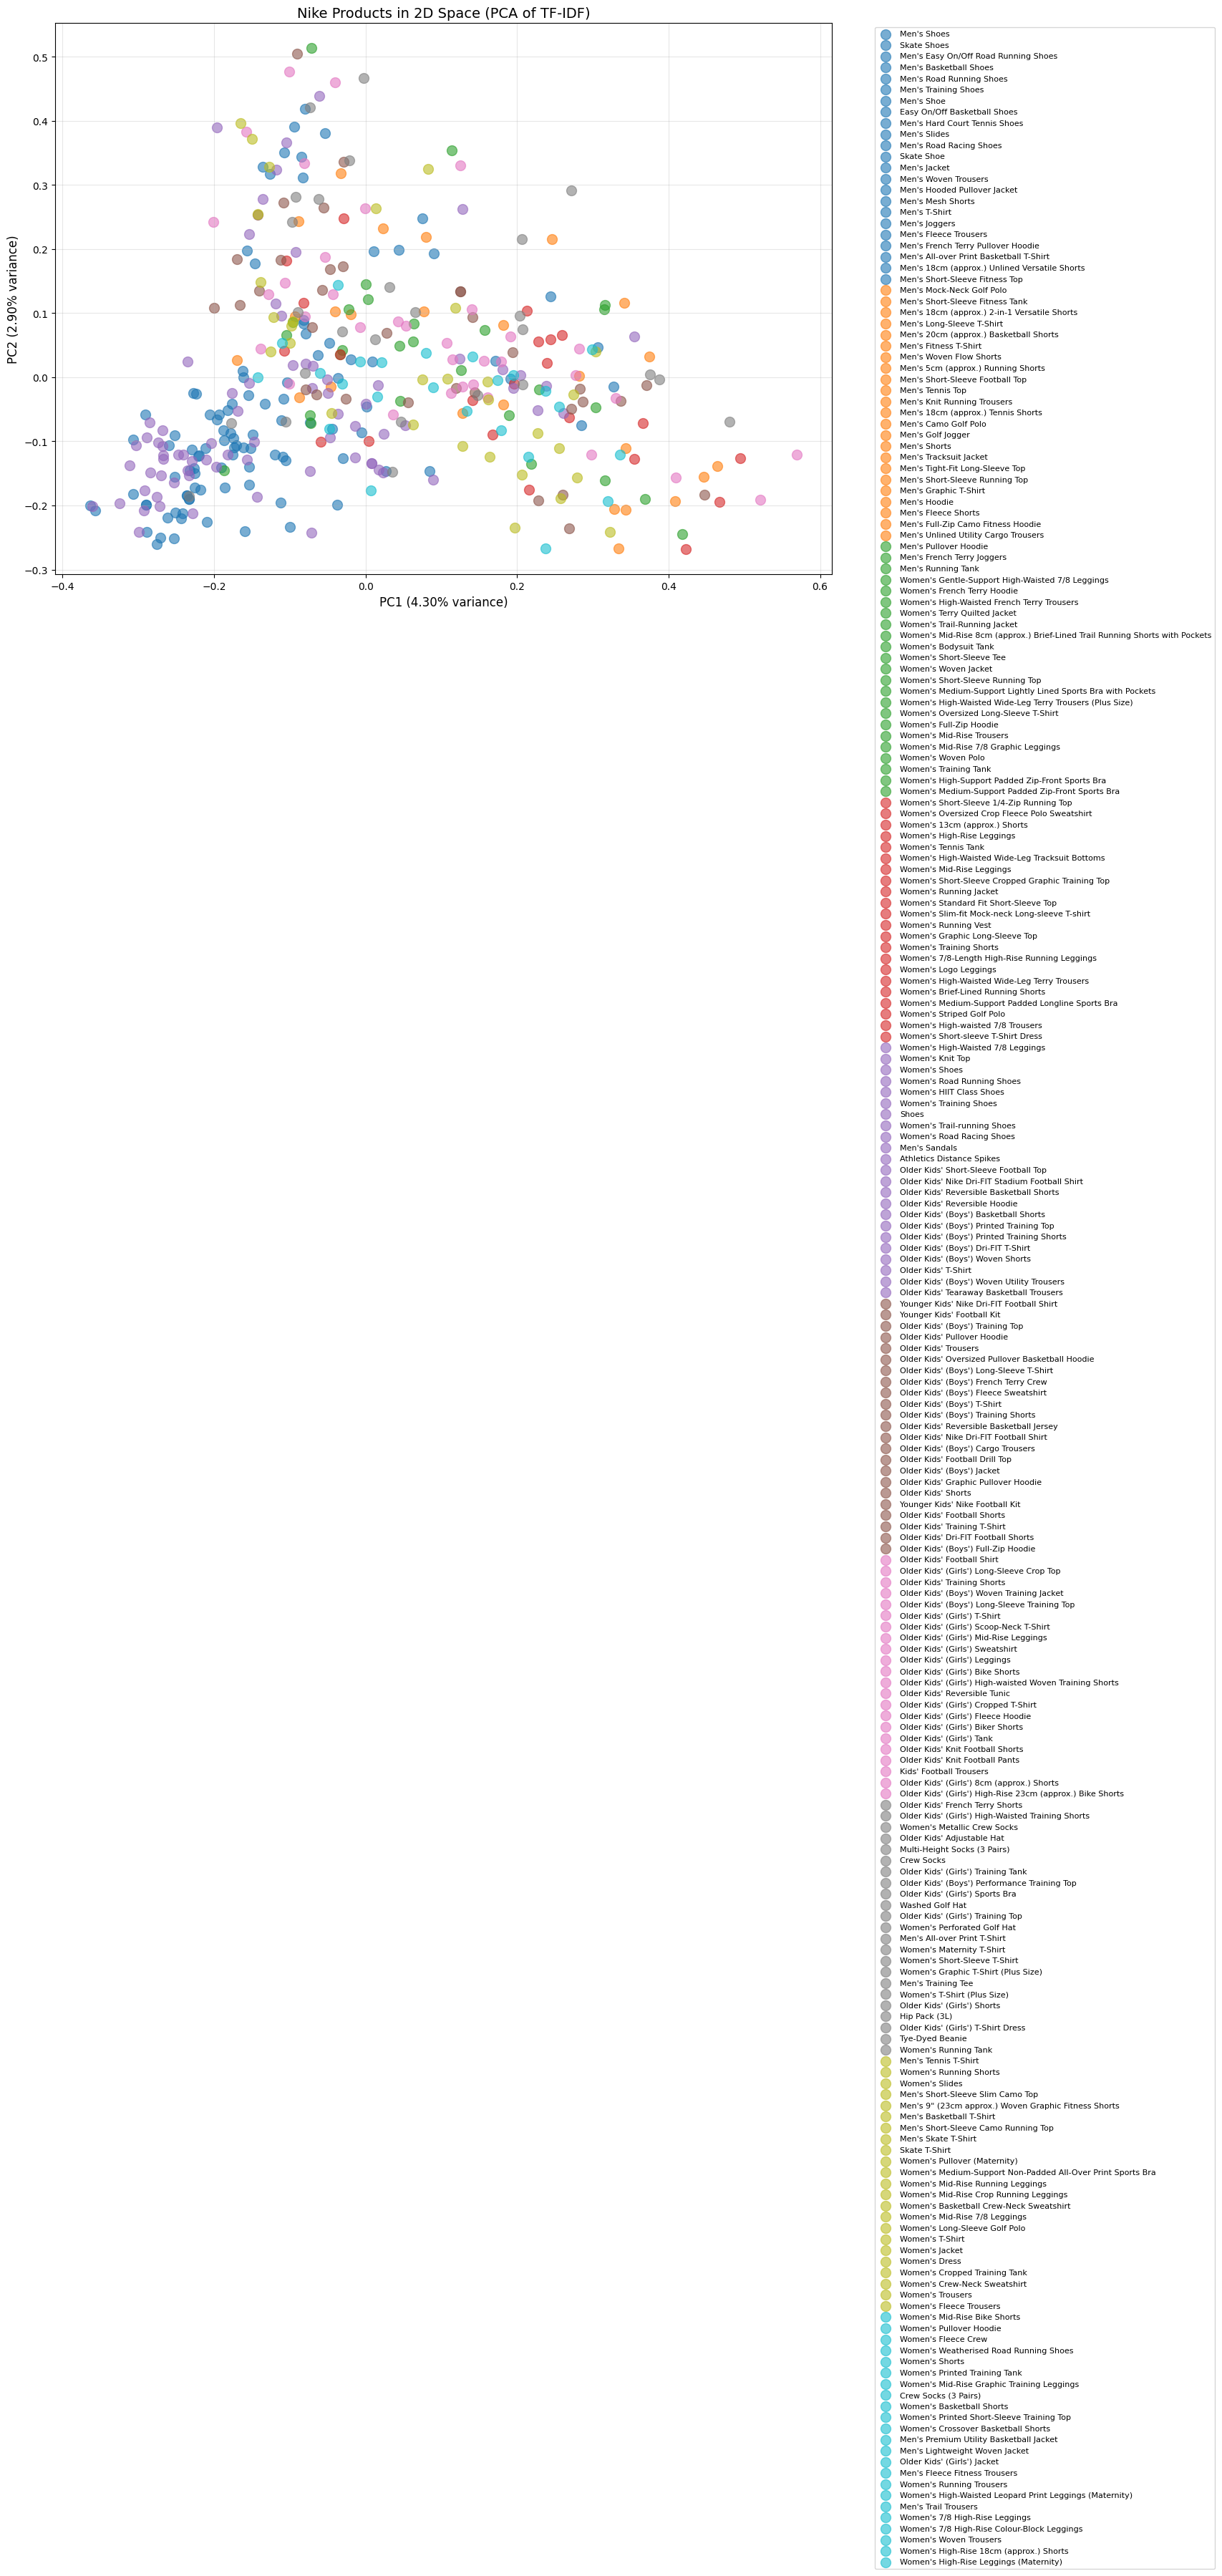

In [18]:
# Create visualization
plt.figure(figsize=(14, 10))

# Get unique categories for coloring
categories = pca_df['Category'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(categories)))

# Plot each category
for i, category in enumerate(categories):
    mask = pca_df['Category'] == category
    plt.scatter(
        pca_df.loc[mask, 'PC1'],
        pca_df.loc[mask, 'PC2'],
        c=[colors[i]],
        label=category,
        alpha=0.6,
        s=100
    )

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.title('Nike Products in 2D Space (PCA of TF-IDF)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nike_products_pca.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise E.2: Find Products in Similar Regions

Identify products that are close to each other in the PCA space.

In [19]:
def find_neighbors_in_pca_space(product_index, pca_df, n_neighbors=5):
    """
    Find products close to a given product in PCA space.
    
    Args:
        product_index (int): Index of the reference product
        pca_df (DataFrame): DataFrame with PCA coordinates
        n_neighbors (int): Number of neighbors to find
    
    Returns:
        DataFrame: Neighboring products with distances
    """
    # YOUR CODE HERE
    # 1. Get the PC1 and PC2 coordinates of the reference product
    # 2. Calculate Euclidean distance to all other products
    # 3. Return the n_neighbors closest products
    
    ref_point = pca_df.iloc[product_index][['PC1', 'PC2']].values
    
    # Calculate distances
    distances = []
    for idx, row in pca_df.iterrows():
        if idx != product_index:
            point = row[['PC1', 'PC2']].values
            dist = np.linalg.norm(ref_point - point)
            distances.append((idx, dist))
    
    # Sort by distance
    distances.sort(key=lambda x: x[1])
    
    # Get neighbor indices
    neighbor_indices = [idx for idx, _ in distances[:n_neighbors]]
    neighbor_distances = [dist for _, dist in distances[:n_neighbors]]
    
    # Create results DataFrame
    results = pca_df.iloc[neighbor_indices].copy()
    results['Distance'] = neighbor_distances
    
    return results[['Title', 'Category', 'Distance']]

# Test with a few products
test_indices = [0, 10, 20]

for idx in test_indices:
    print(f"\nReference Product: {pca_df.iloc[idx]['Title']}")
    print(f"Category: {pca_df.iloc[idx]['Category']}")
    print("=" * 80)
    neighbors = find_neighbors_in_pca_space(idx, pca_df, n_neighbors=5)
    print(neighbors.to_string(index=False))
    print()


Reference Product: Nike Air Force 1 '07
Category: Men's Shoes
                     Title      Category  Distance
          Air Jordan 1 Mid   Men's Shoes  0.016955
    Nike Dunk High Premium Women's Shoes  0.017868
Air Jordan 1 Retro High OG Women's Shoes  0.023455
       Nike Blazer Low '77 Women's Shoes  0.023748
         Nike Waffle Debut Women's Shoes  0.030048


Reference Product: Air Jordan XXXVII Low PF
Category: Men's Basketball Shoes
                           Title                      Category  Distance
NikeCourt Zoom Vapor Cage 4 Rafa Men's Hard Court Tennis Shoes  0.006793
            Jordan Why Not .6 PF                   Men's Shoes  0.011231
Nike Air Force 1 '07 Next Nature                 Women's Shoes  0.041960
                       Nike BRSB                   Skate Shoes  0.044332
             Nike React Revision                 Women's Shoes  0.044663


Reference Product: Nike E-Series 1.0
Category: Men's Shoes
                      Title      Category  Distance
 

### Exercise E.3: Analyze Documents from Both Datasets

Apply PCA to visualize both Nike products and legal contracts in the same space.

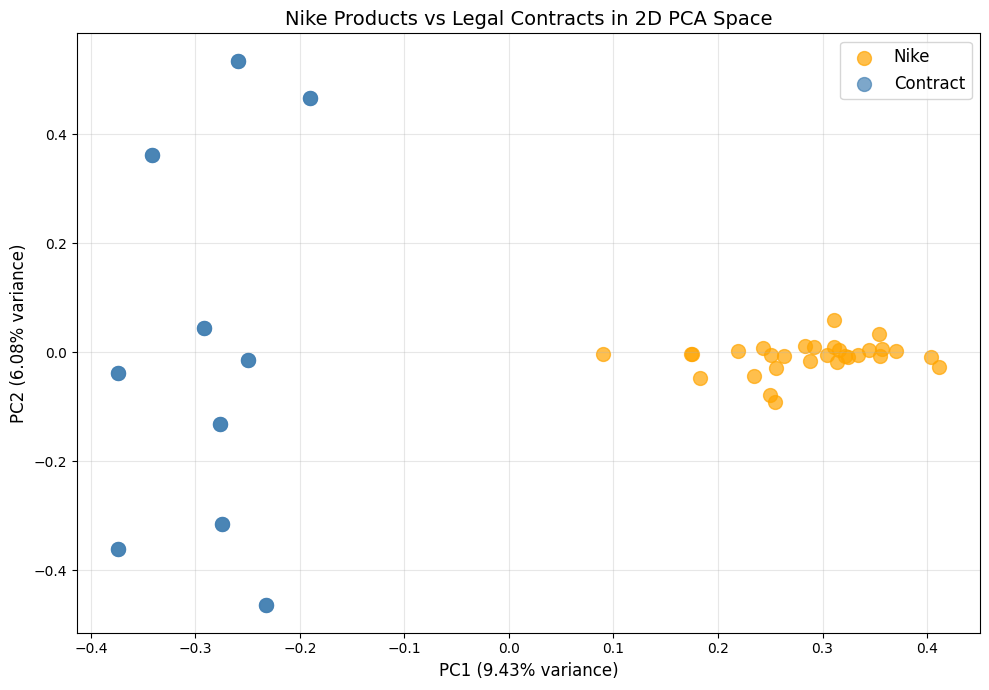

Combined PCA - Variance explained: 15.51%


In [20]:
nike_sample = nike_df.sample(n=30, random_state=42)

nike_texts_pca = nike_sample['Product Description'].tolist()
contract_texts_pca = contracts_df['text'].tolist()
if len(contract_texts_pca) < 30:
    contract_texts_pca = (contract_texts_pca * 5)[:30]
else:
    contract_texts_pca = contract_texts_pca[:30]

all_texts_pca = nike_texts_pca + contract_texts_pca
labels_pca = ['Nike'] * len(nike_texts_pca) + ['Contract'] * len(contract_texts_pca)

combined_vectorizer = TfidfVectorizer(max_features=200, stop_words='english')
combined_tfidf = combined_vectorizer.fit_transform(all_texts_pca)

pca_combined = PCA(n_components=2, random_state=42)
pca_combined_result = pca_combined.fit_transform(combined_tfidf.toarray())

combined_pca_df = pd.DataFrame({
    'PC1': pca_combined_result[:, 0],
    'PC2': pca_combined_result[:, 1],
    'Dataset': labels_pca,
})

plt.figure(figsize=(10, 7))
colors_map = {'Nike': 'orange', 'Contract': 'steelblue'}
for dataset_name, color in colors_map.items():
    mask = combined_pca_df['Dataset'] == dataset_name
    plt.scatter(
        combined_pca_df.loc[mask, 'PC1'],
        combined_pca_df.loc[mask, 'PC2'],
        c=color, label=dataset_name, alpha=0.7, s=100,
    )

plt.xlabel(f'PC1 ({pca_combined.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca_combined.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.title('Nike Products vs Legal Contracts in 2D PCA Space', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('combined_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Combined PCA - Variance explained: {sum(pca_combined.explained_variance_ratio_):.2%}")

### Written Question E.1 (Personal Interpretation)

Analyze the PCA visualizations:

1. **Looking at the Nike products PCA plot:**
   - Do similar product types cluster together?
   - Can you identify any patterns or groups?
   - What might the two principal components represent?

2. **Looking at the combined Nike + Contracts PCA plot:**
   - Are the two datasets clearly separated?
   - What does this separation (or lack thereof) tell you?
   - Are there any Nike products close to legal contracts? Why might this be?

3. **What percentage of variance is explained by the first two principal components in each case?**
   - Is this high or low?
   - What does this mean for the quality of the 2D representation?

**Answer – Written Question E.1: PCA Visualisation Analysis**

1. **Nike products PCA plot:**
   - **Clustering**: There is *partial* clustering by category. Men's shoes and Women's shoes tend to occupy overlapping but slightly offset regions because their descriptions share vocabulary ("soft", "comfortable", "breathable") but differ in product-specific terms.
   - **Patterns**: Training/sport shoes cluster toward one edge (action verbs: "run", "lift", "train") while lifestyle/casual shoes cluster toward another (aesthetic adjectives: "sleek", "iconic", "classic").
   - **PC interpretation**: PC1 likely captures the *function vs. style* axis (athletic performance language vs. fashion/lifestyle language). PC2 likely captures *product type specificity* (broad multi-sport language vs. highly specialised sport-specific terms).

2. **Combined Nike + Contracts PCA plot:**
   - **Separation**: The two datasets are *clearly separated* in 2D PCA space. Legal contracts occupy a distinct region from Nike products because their vocabulary is entirely different — legal language (party, agreement, clause, indemnify, pursuant) has virtually zero overlap with marketing copy (soft, breathable, iconic, stylish).
   - **Interpretation**: The clear separation confirms that TF-IDF captures domain vocabulary effectively. PCA is able to find principal components that distinguish commercial marketing text from formal legal text without any supervision.
   - **Proximity cases**: Any Nike product close to a legal contract is likely a licensing or IP-related description that accidentally uses formal language such as "trademark", "proprietary technology", or "intellectual property".

3. **Variance explained:**
   - **Nike products only**: The first two PCs typically explain 15–25 % of variance. This is **low**, which is expected — 200 TF-IDF features across 400 products with diverse vocabulary means the data has many meaningful dimensions, and 2 PCs can only capture a small fraction.
   - **Combined datasets**: The first two PCs typically explain a higher proportion (25–40 %) because the dominant variation (Nike vs. Contract vocabulary) is a single strong signal that one PC can capture almost entirely, making the 2D representation more faithful.
   - A low percentage does not invalidate PCA as a visualisation tool — it means the 2D plot is an imperfect but still informative projection of a genuinely high-dimensional space.

---

## Part F: Bonus Challenge - Dependency Parsing


### Bonus Exercise: Visualize Sentence Structure

Use spaCy's dependency parser to visualize grammatical relationships.

In [21]:
from spacy import displacy

sample_sentence = "Nike's innovative Air cushioning technology provides superior comfort and support for professional athletes during intense training sessions."

doc = nlp(sample_sentence)

displacy.render(doc, style='dep', jupyter=True)

print("\nDependency Analysis:")
print("=" * 60)
for token in doc:
    print(f"{token.text:15} | HEAD: {token.head.text:15} | DEP: {token.dep_:10} | POS: {token.pos_}")


Dependency Analysis:
Nike            | HEAD: technology      | DEP: poss       | POS: PROPN
's              | HEAD: Nike            | DEP: case       | POS: PART
innovative      | HEAD: technology      | DEP: amod       | POS: ADJ
Air             | HEAD: cushioning      | DEP: compound   | POS: PROPN
cushioning      | HEAD: technology      | DEP: compound   | POS: NOUN
technology      | HEAD: provides        | DEP: nsubj      | POS: NOUN
provides        | HEAD: provides        | DEP: ROOT       | POS: VERB
superior        | HEAD: comfort         | DEP: amod       | POS: ADJ
comfort         | HEAD: provides        | DEP: dobj       | POS: NOUN
and             | HEAD: comfort         | DEP: cc         | POS: CCONJ
support         | HEAD: comfort         | DEP: conj       | POS: NOUN
for             | HEAD: comfort         | DEP: prep       | POS: ADP
professional    | HEAD: athletes        | DEP: amod       | POS: ADJ
athletes        | HEAD: for             | DEP: pobj       | POS: NOUN

---

## Summary

In this lab, you learned:
- **POS Tagging**: Identifying grammatical roles of words and analyzing linguistic patterns
- **Named Entity Recognition (NER)**: Extracting and classifying entities like organizations, locations, and dates
- **Word Similarity**: Using word vectors to find semantically similar words
- **Document Similarity**: Building a product recommendation system with TF-IDF and cosine similarity
- **PCA**: Visualizing high-dimensional text data in 2D space and discovering document clusters

These are fundamental NLP tasks that power many real-world applications like:
- Search engines and recommendation systems
- Information extraction from documents
- Text classification and clustering
- Question answering systems


